# MorphAgent HSC — Figure 3 (Young / Old)

One notebook. Discovery inputs come from `HSC_Fig3a_YoungOld_reproduction_20260916.zip`; the 162-cell transfer tables come from `HSC_Fig3a_YoungOld_reproduction_20260916 2`.

The locked 25-name list is in `selected_features.csv`. Every name is present in the 110-cell discovery table and in both 162-cell transfer tables (confocal and blurred). No fuzzy matching.

Reported numbers are **5-fold stratified CV, repeated 5 times, seed 42**. Scatter plots are fitted on all cells in that panel; `full_roc_auc` is not the reported CV AUC.

| Panel | Input | n | CV ROC AUC |
|-------|--------|--:|------------|
| MorphAgent, fixed 25 image features | discovery | 110 | **0.739** |
| Handcrafted 2 features, polynomial degree 3 | discovery | 110 | **0.575** |
| Transcriptome, top 500 of ranked 2,000 | discovery | 110 | **0.920** |
| Transfer, same 25 features | spinning-disk confocal | 162 (99 young / 63 aged) | **0.905** |
| Same 162 cells after blur, combo 011 | synthetic low-resolution | 162 | **0.795** |


## 0. Paths


In [2]:
from pathlib import Path
import sys
import zipfile
import shutil

HERE = Path.cwd().resolve()
if HERE.name == "notebook":
    TUTORIAL = HERE.parent
elif (HERE / "code").is_dir() and (HERE / "source").is_dir():
    TUTORIAL = HERE
else:
    TUTORIAL = HERE
sys.path.insert(0, str(TUTORIAL / "code"))

import importlib
import paths as P
P = importlib.reload(P)

if not P.FEATURES_CODE_CSV.is_file():
    if not P.FIG3A_ZIP.is_file():
        raise FileNotFoundError(f"Missing {P.FEATURES_CODE_CSV} and {P.FIG3A_ZIP}")
    P.SOURCE_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(P.FIG3A_ZIP) as zf:
        zf.extractall(P.SOURCE_DIR)
    inner = P.SOURCE_DIR / "HSC_Fig3a_YoungOld_reproduction_20260916"
    if inner.is_dir() and not P.FIG3A_BUNDLE.is_dir():
        inner.rename(P.FIG3A_BUNDLE)
    elif inner.is_dir() and P.FIG3A_BUNDLE.is_dir() and inner.resolve() != P.FIG3A_BUNDLE.resolve():
        shutil.rmtree(P.FIG3A_BUNDLE)
        inner.rename(P.FIG3A_BUNDLE)

src2 = getattr(P, "FIG3A_SRC_DIR", None)
if src2 is not None and Path(src2).is_dir():
    extra = {
        Path(src2) / "input" / "merged_numeric_features_cleaned.csv": P.FIG3A_INPUT / "merged_numeric_features_cleaned.csv",
        Path(src2) / "input" / "merged_blurred_features.csv": P.FIG3A_INPUT / "merged_blurred_features.csv",
        Path(src2) / "scripts" / "run_image_feature_young_old_pca12_selected_blurred_grid.py": P.FIG3A_SCRIPTS / "run_image_feature_young_old_pca12_selected_blurred_grid.py",
    }
    for src, dst in extra.items():
        if src.is_file() and not dst.is_file():
            dst.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src, dst)

sys.path.insert(0, str(P.FIG3A_SCRIPTS))
print("Tutorial root:", P.ROOT)
print("Fig3a input  :", P.FIG3A_INPUT)
print("110-cell CSV :", P.FEATURES_CODE_CSV, "exists=", P.FEATURES_CODE_CSV.is_file())
print("162-cell CSV :", P.FEATURES_TRANSFER_CSV, "exists=", P.FEATURES_TRANSFER_CSV.is_file())
print("blurred CSV  :", P.FEATURES_BLURRED_CSV, "exists=", P.FEATURES_BLURRED_CSV.is_file())
print("25 features  :", P.SELECTED_FEATURES_CSV)
print("output dir   :", P.OUTPUT_DIR)


Tutorial root: /Users/yez/Desktop/tutorial_HSC
Fig3a input  : /Users/yez/Desktop/tutorial_HSC/source/fig3a_bundle/input
110-cell CSV : /Users/yez/Desktop/tutorial_HSC/source/fig3a_bundle/input/features_code_filtered_old_plus_20210624_Young.csv exists= True
162-cell CSV : /Users/yez/Desktop/tutorial_HSC/source/fig3a_bundle/input/merged_numeric_features_cleaned.csv exists= True
blurred CSV  : /Users/yez/Desktop/tutorial_HSC/source/fig3a_bundle/input/merged_blurred_features.csv exists= True
25 features  : /Users/yez/Desktop/tutorial_HSC/source/fig3a_bundle/input/selected_features.csv
output dir   : /Users/yez/Desktop/tutorial_HSC/data/outputs


## 1. Locked 25-feature list

These are the names used for MorphAgent and for transfer. All 25 exist as columns in the 110-cell discovery table and in both 162-cell tables.


In [3]:
import pandas as pd
from IPython.display import display, Markdown, Image

names = pd.read_csv(P.SELECTED_FEATURES_CSV)
display(names)
print(f"{len(names)} features")

img = pd.read_csv(P.FEATURES_CODE_CSV)
print(f"image table: {img.shape[0]} cells × {img.shape[1]-1} features")
print(img.sample_id.head().tolist())
age = img.sample_id.astype(str).str.contains("young", case=False)
print("Young", int(age.sum()), "Old", int((~age).sum()))
missing = [n for n in names.feature if n not in img.columns]
print("missing from image table:", missing if missing else "none")
assert not missing

for label, path in (
    ("transfer 162", P.FEATURES_TRANSFER_CSV),
    ("blurred 162", P.FEATURES_BLURRED_CSV),
):
    df = pd.read_csv(path)
    sid = df.sample_id.astype(str)
    print(
        f"{label}: {df.shape[0]} cells, "
        f"Young={int(sid.str.contains('young', case=False).sum())}, "
        f"Old={int(sid.str.contains('old', case=False).sum())}, "
        f"missing 25={ [n for n in names.feature if n not in df.columns] or 'none' }"
    )


,feature
0,background_mito_signal_to_noise
1,mitochondria_to_background_intensity_contrast
2,nucleus_to_mitochondria_intensity_ratio
3,background_noise_robust_snr
4,mitochondria_intensity_entropy_within_cell
5,median_mitochondria_object_area
6,mitochondria_radial_distribution_entropy
7,mitochondria_neighbor_intensity_variogram_slope
8,elongated_mito_fraction_by_aspect_ratio
9,mitochondria_polarization_toward_niche_side


25 features
image table: 110 cells × 250 features
['20210518_Old_seq_c1', '20210518_Old_seq_c10', '20210518_Old_seq_c11', '20210518_Old_seq_c12', '20210518_Old_seq_c13']
Young 42 Old 68
missing from image table: none
transfer 162: 162 cells, Young=99, Old=63, missing 25=none
blurred 162: 162 cells, Young=99, Old=63, missing 25=none


## 2. MorphAgent 25 features — Figure 3a left

Standardize (median impute) → 2D PCA on the 25 columns → L2 logistic (`liblinear`, `class_weight=balanced`). CV: 5×5, seed 42.


,feature_count,missing_feature_count,balanced_accuracy,balanced_accuracy_std,roc_auc,roc_auc_std,full_balanced_accuracy,full_roc_auc,group_plot_png,group_plot_svg,pseudotime_plot_png,pseudotime_plot_svg
0,25,0,0.683092,0.072667,0.738697,0.093259,0.702731,0.753852,/Users/yez/Desktop/tutorial_HSC/data/outputs/i...,/Users/yez/Desktop/tutorial_HSC/data/outputs/i...,/Users/yez/Desktop/tutorial_HSC/data/outputs/i...,/Users/yez/Desktop/tutorial_HSC/data/outputs/i...


**MorphAgent CV AUC = 0.739** (paper 0.739). Used 25 / missing 0.

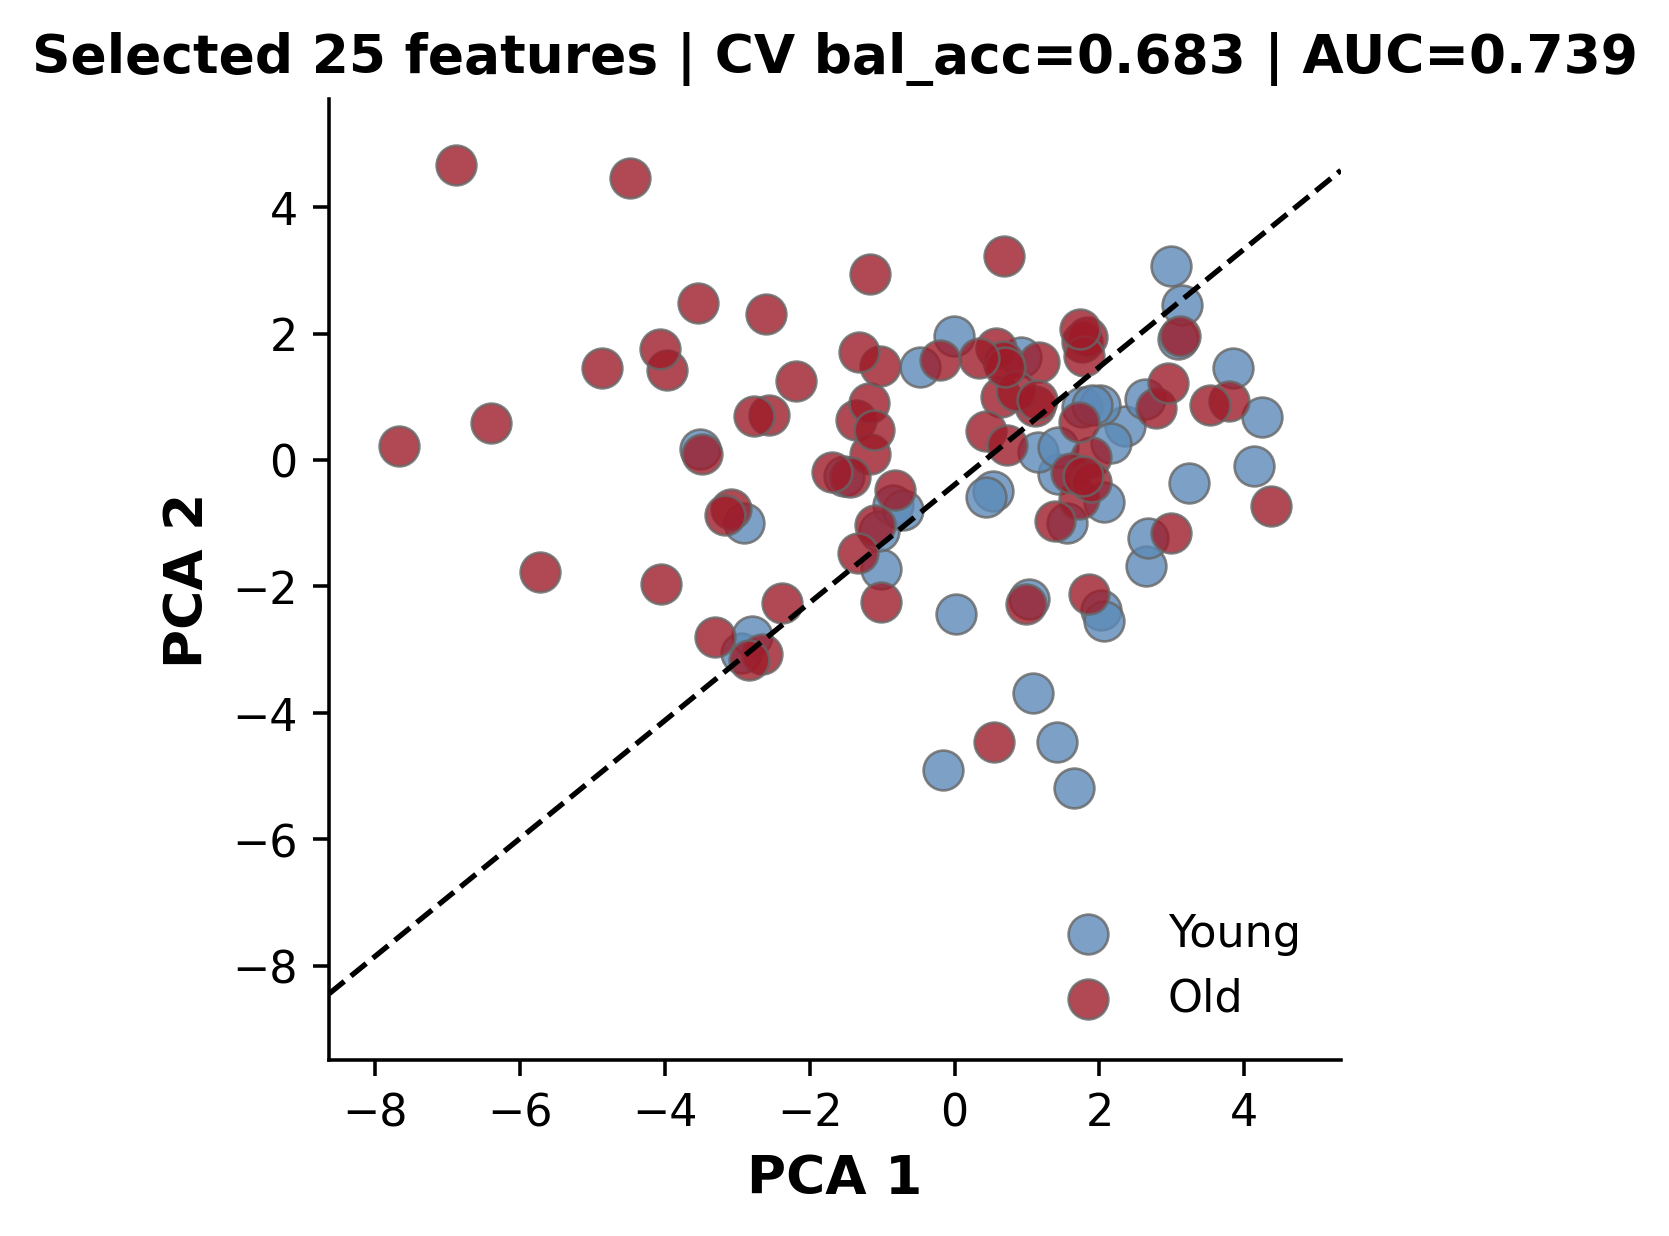

In [4]:
import run_image_feature_young_old_pca12_selected as selected
import run_image_feature_young_old_pca12_search as search
selected = importlib.reload(selected)
search = importlib.reload(search)

P.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
img_out = P.OUTPUT_DIR / "image_morphagent_25"
img_res = selected.run_analysis(
    features_csv=P.FEATURES_CODE_CSV,
    selected_features_csv=P.SELECTED_FEATURES_CSV,
    out_dir=img_out,
    random_state=42,
    cv_splits=5,
    cv_repeats=5,
    pseudotime_csv=P.PSEUDOTIME_CSV,
    pseudotime_palette=P.PSEUDOTIME_PALETTE,
)
img_sum = pd.read_csv(img_out / "pca12_summary.csv")
display(img_sum)
display(Markdown(
    f"**MorphAgent CV AUC = {img_res['roc_auc']:.3f}** (paper 0.739). "
    f"Used {img_res['used_feature_count']} / missing {img_res['missing_feature_count']}."
))
display(Image(filename=str(img_out / "pca12_group_scatter.png")))


## 3. Transcriptome — Figure 3a right

Keep the 2,000 highest-variance genes, rank those 2,000 by ANOVA F on Young/Old, evaluate the top 500 in PCA-plane logistic CV. Same 110 cells.


,subset_size,balanced_accuracy,balanced_accuracy_std,roc_auc,roc_auc_std,full_balanced_accuracy,full_roc_auc,output_dir
0,500,0.808843,0.077143,0.920394,0.045045,0.819328,0.921919,/Users/yez/Desktop/tutorial_HSC/data/outputs/t...
1,1000,0.769408,0.068005,0.853065,0.062666,0.788165,0.859594,/Users/yez/Desktop/tutorial_HSC/data/outputs/t...
2,1500,0.743175,0.075162,0.798843,0.080646,0.754202,0.798319,/Users/yez/Desktop/tutorial_HSC/data/outputs/t...
3,2000,0.709637,0.074904,0.737912,0.097775,0.720238,0.751751,/Users/yez/Desktop/tutorial_HSC/data/outputs/t...


**Transcriptome top-500 CV AUC = 0.920** (paper 0.920).

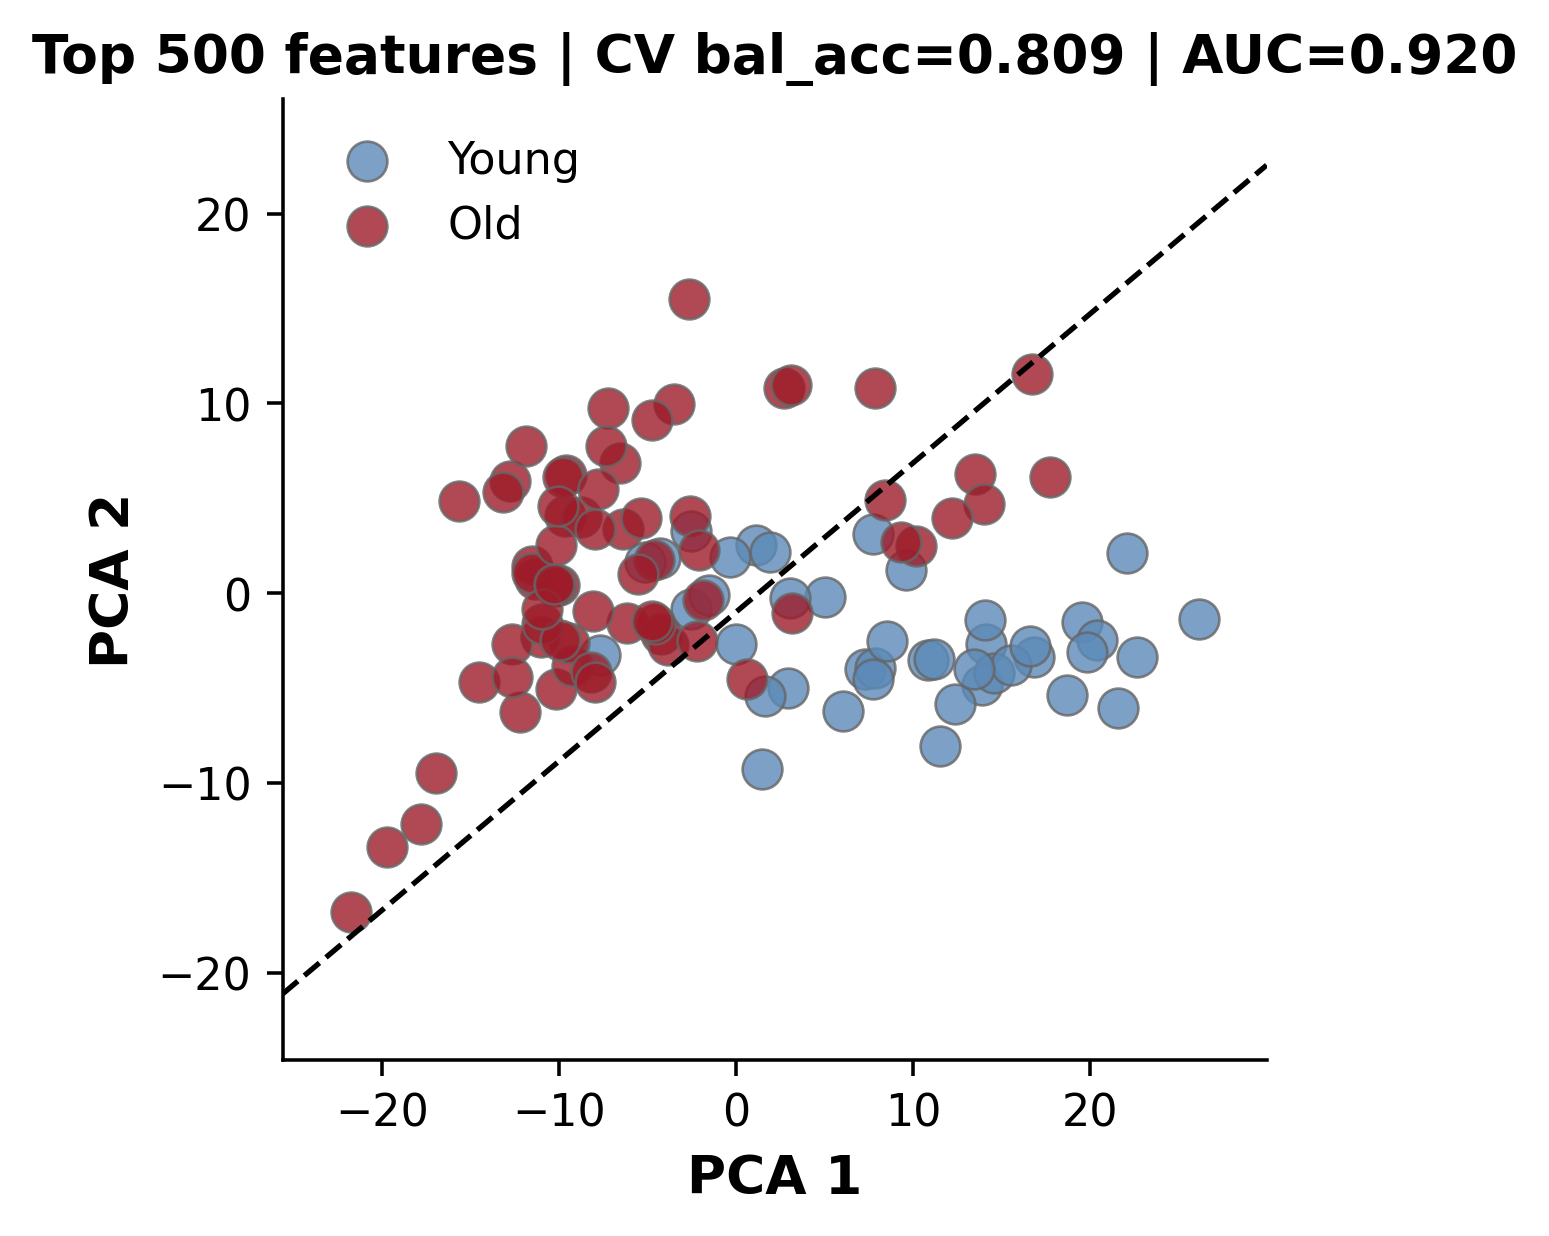

In [5]:
omics_out = P.OUTPUT_DIR / "transcriptome_top500"
omics_res = search.run_analysis(
    features_csv=P.OMICS_TSV,
    out_dir=omics_out,
    random_state=42,
    prefilter_top_n=2000,
    subset_sizes=[500, 1000, 1500, 2000],
    cv_splits=5,
    cv_repeats=5,
    pseudotime_csv=P.PSEUDOTIME_CSV,
    pseudotime_palette=P.PSEUDOTIME_PALETTE,
    top_variable_features=2000,
    ranked_subsets=True,
)
omics_sum = pd.read_csv(omics_out / "pca12_search_summary.csv")
display(omics_sum)
row500 = omics_sum.loc[omics_sum.subset_size == 500].iloc[0]
display(Markdown(
    f"**Transcriptome top-500 CV AUC = {row500.roc_auc:.3f}** (paper 0.920)."
))
display(Image(filename=str(omics_out / "top_500_features" / "pca12_group_scatter.png")))


## 4. Handcrafted two features — Figure 3a middle

`mitochondria_elongation_ratio` and `mitochondria_polarization_index`, used as the two axes (no PCA). Classifier is degree-3 polynomial + L2 logistic. Linear logistic on the same two axes is ~0.406, not 0.575.


,subset_size,feature_count,balanced_accuracy,balanced_accuracy_std,roc_auc,roc_auc_std,full_balanced_accuracy,full_roc_auc,output_dir
0,2,2,0.520375,0.075337,0.574771,0.070937,0.572479,0.614496,/Users/yez/Desktop/tutorial_HSC/data/outputs/h...


**Handcrafted poly3 CV AUC = 0.575** (paper 0.575).

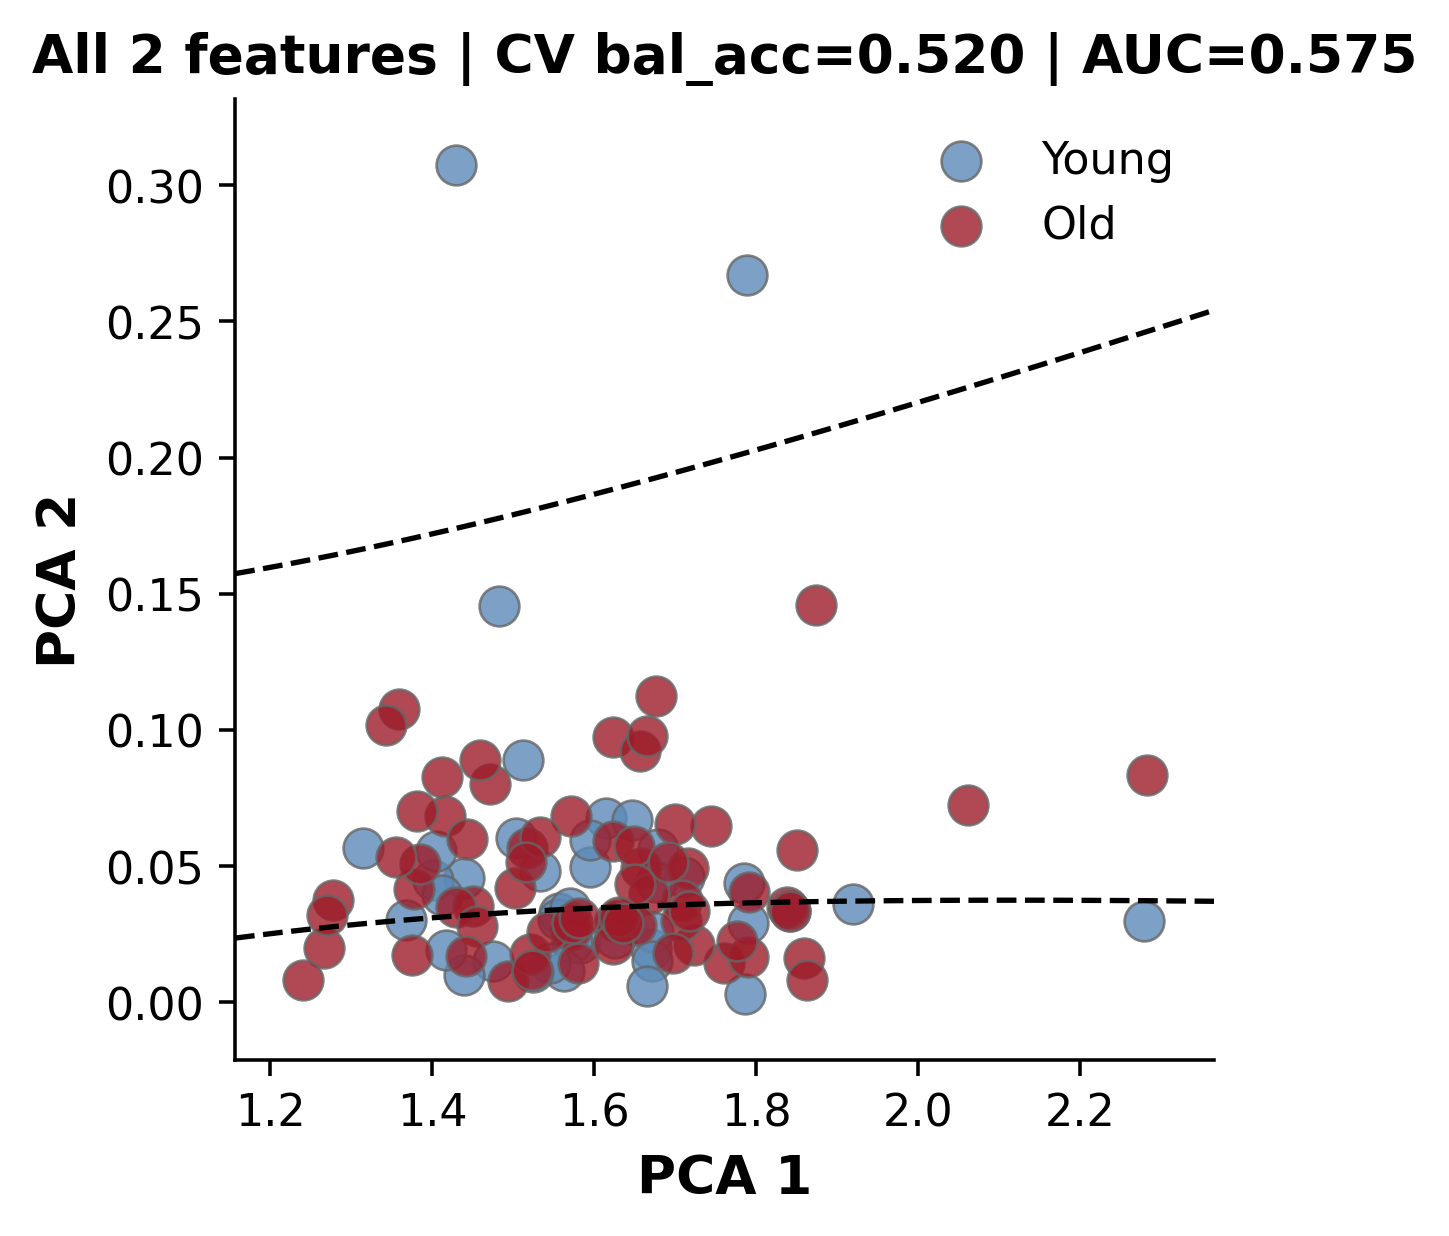

In [6]:
man_out = P.OUTPUT_DIR / "handcrafted_poly3"
man_res = search.run_analysis(
    features_csv=P.FEATURES_MANUAL_CSV,
    out_dir=man_out,
    random_state=42,
    cv_splits=5,
    cv_repeats=5,
    use_all_features=True,
    use_raw_two_features_as_pca=True,
    raw_two_features_classifier="poly3",
    pseudotime_csv=P.PSEUDOTIME_CSV,
)
man_sum = pd.read_csv(man_out / "pca12_search_summary.csv")
display(man_sum)
display(Markdown(
    f"**Handcrafted poly3 CV AUC = {man_res['best_roc_auc']:.3f}** (paper 0.575)."
))
display(Image(filename=str(man_out / "all_features" / "pca12_group_scatter.png")))


## 5. Transfer — Figure 3d confocal (162 cells)

Same frozen 25 features, no reselection, on `merged_numeric_features_cleaned.csv` (99 young / 63 aged). Paper AUC = 0.905.


,feature_count,missing_feature_count,balanced_accuracy,balanced_accuracy_std,roc_auc,roc_auc_std,full_balanced_accuracy,full_roc_auc,group_plot_png,group_plot_svg,pseudotime_plot_png,pseudotime_plot_svg
0,25,0,0.840753,0.076498,0.904638,0.061044,0.930014,0.976431,/Users/yez/Desktop/tutorial_HSC/data/outputs/t...,/Users/yez/Desktop/tutorial_HSC/data/outputs/t...,NaN,NaN


**Transfer CV AUC = 0.905** (paper 0.905). Used 25 / missing 0.

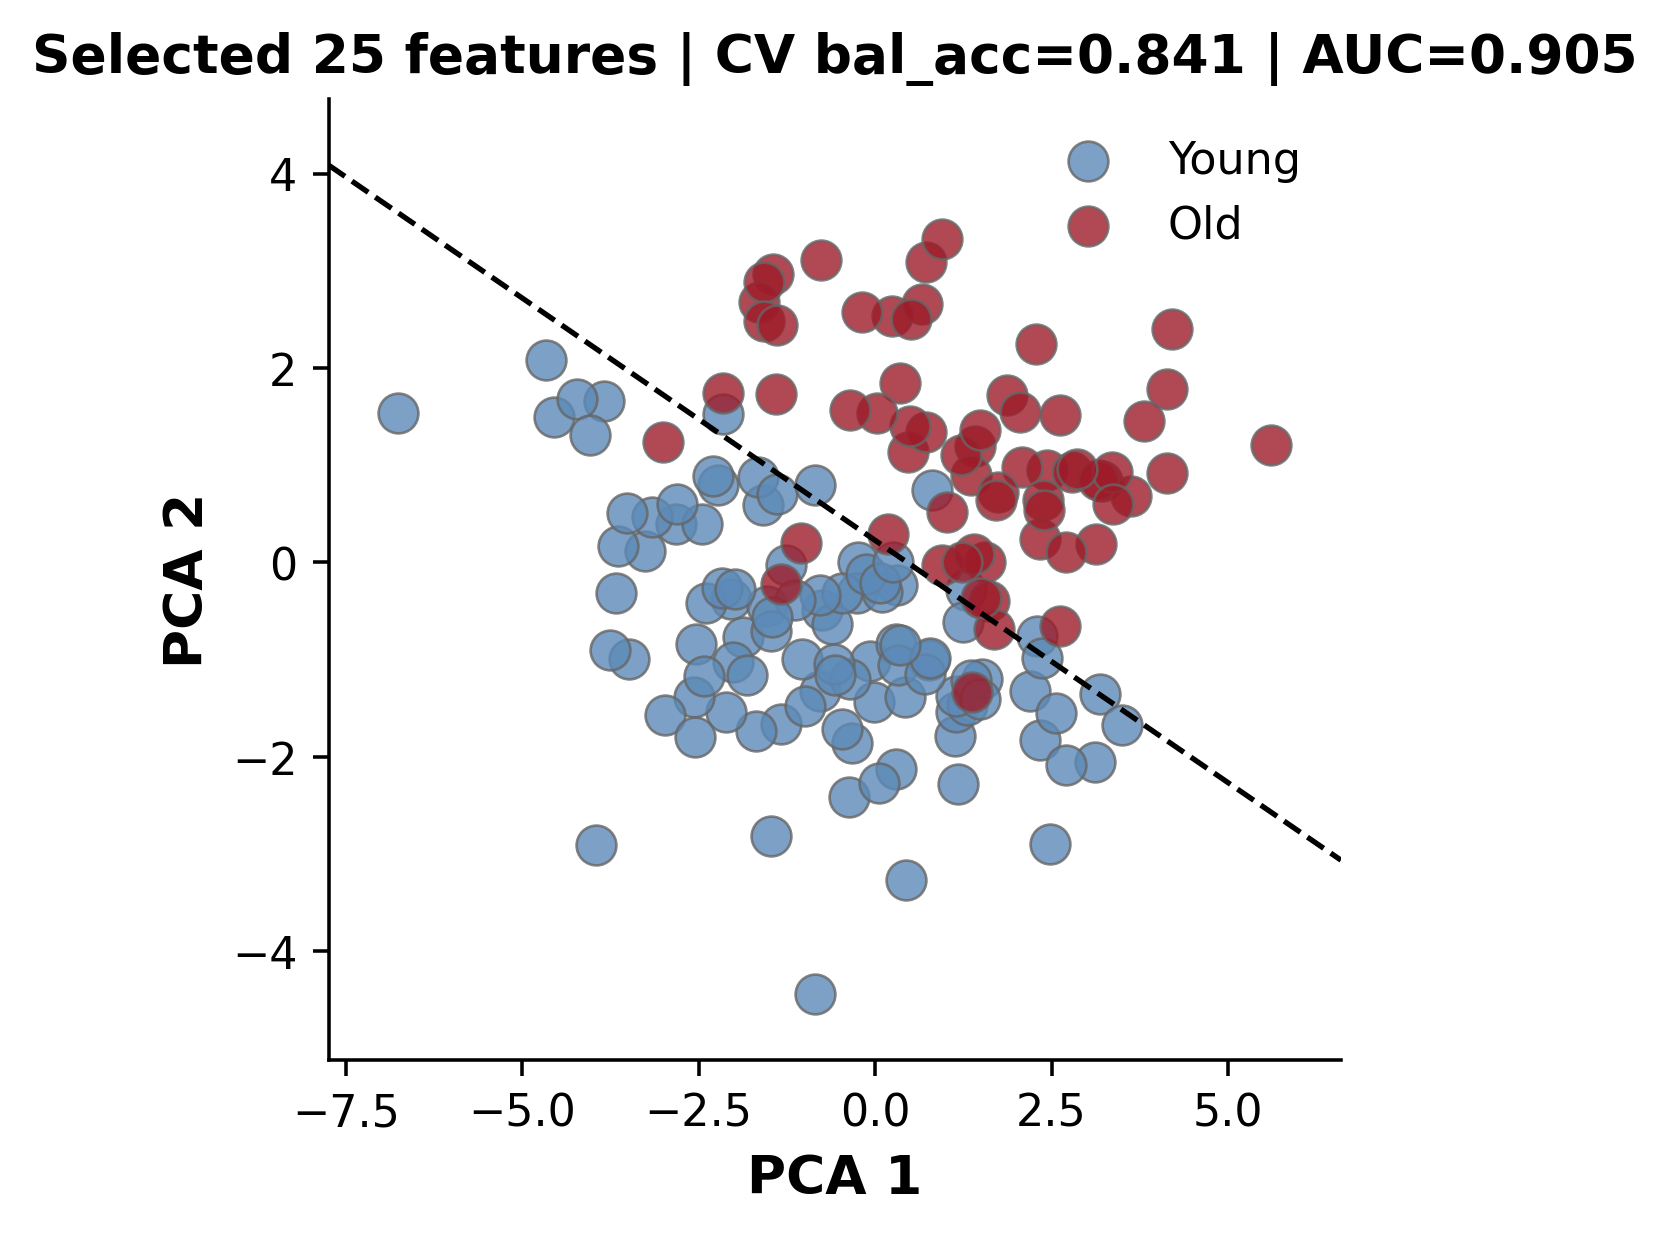

In [7]:
tr_out = P.OUTPUT_DIR / "transfer_fixed25_validation162"
tr_res = selected.run_analysis(
    features_csv=P.FEATURES_TRANSFER_CSV,
    selected_features_csv=P.SELECTED_FEATURES_CSV,
    out_dir=tr_out,
    random_state=42,
    cv_splits=5,
    cv_repeats=5,
)
tr_sum = pd.read_csv(tr_out / "pca12_summary.csv")
display(tr_sum)
display(Markdown(
    f"**Transfer CV AUC = {tr_res['roc_auc']:.3f}** (paper 0.905). "
    f"Used {tr_res['used_feature_count']} / missing {tr_res['missing_feature_count']}."
))
display(Image(filename=str(tr_out / "pca12_group_scatter.png")))


## 6. Blurred transfer — Figure 3d synthetic low-resolution

Same 162 cells and the same 25 features on `merged_blurred_features.csv`. The paper panel is **combo 011** (`standard` scaler, clip 0.02, log1p, no PCA whitening), CV AUC = 0.795. The 36-combination grid's highest AUC is a different combo (~0.835) and is not the published panel.


,combo_name,feature_count,scaler,clip_quantile,log1p,pca_whiten,cv_balanced_accuracy,cv_balanced_accuracy_std,cv_roc_auc,cv_roc_auc_std,full_balanced_accuracy,full_roc_auc,spread_score,plot_svg,plot_png
0,combo_011__scaler_standard__clip_0.02__log1p_1...,25,standard,0.02,True,False,0.723065,0.064713,0.7947,0.068519,0.725108,0.803752,2.897832,/Users/yez/Desktop/tutorial_HSC/data/outputs/b...,/Users/yez/Desktop/tutorial_HSC/data/outputs/b...


**Blurred combo 011 CV AUC = 0.795** (paper 0.795). `combo_011__scaler_standard__clip_0.02__log1p_1__whiten_0`

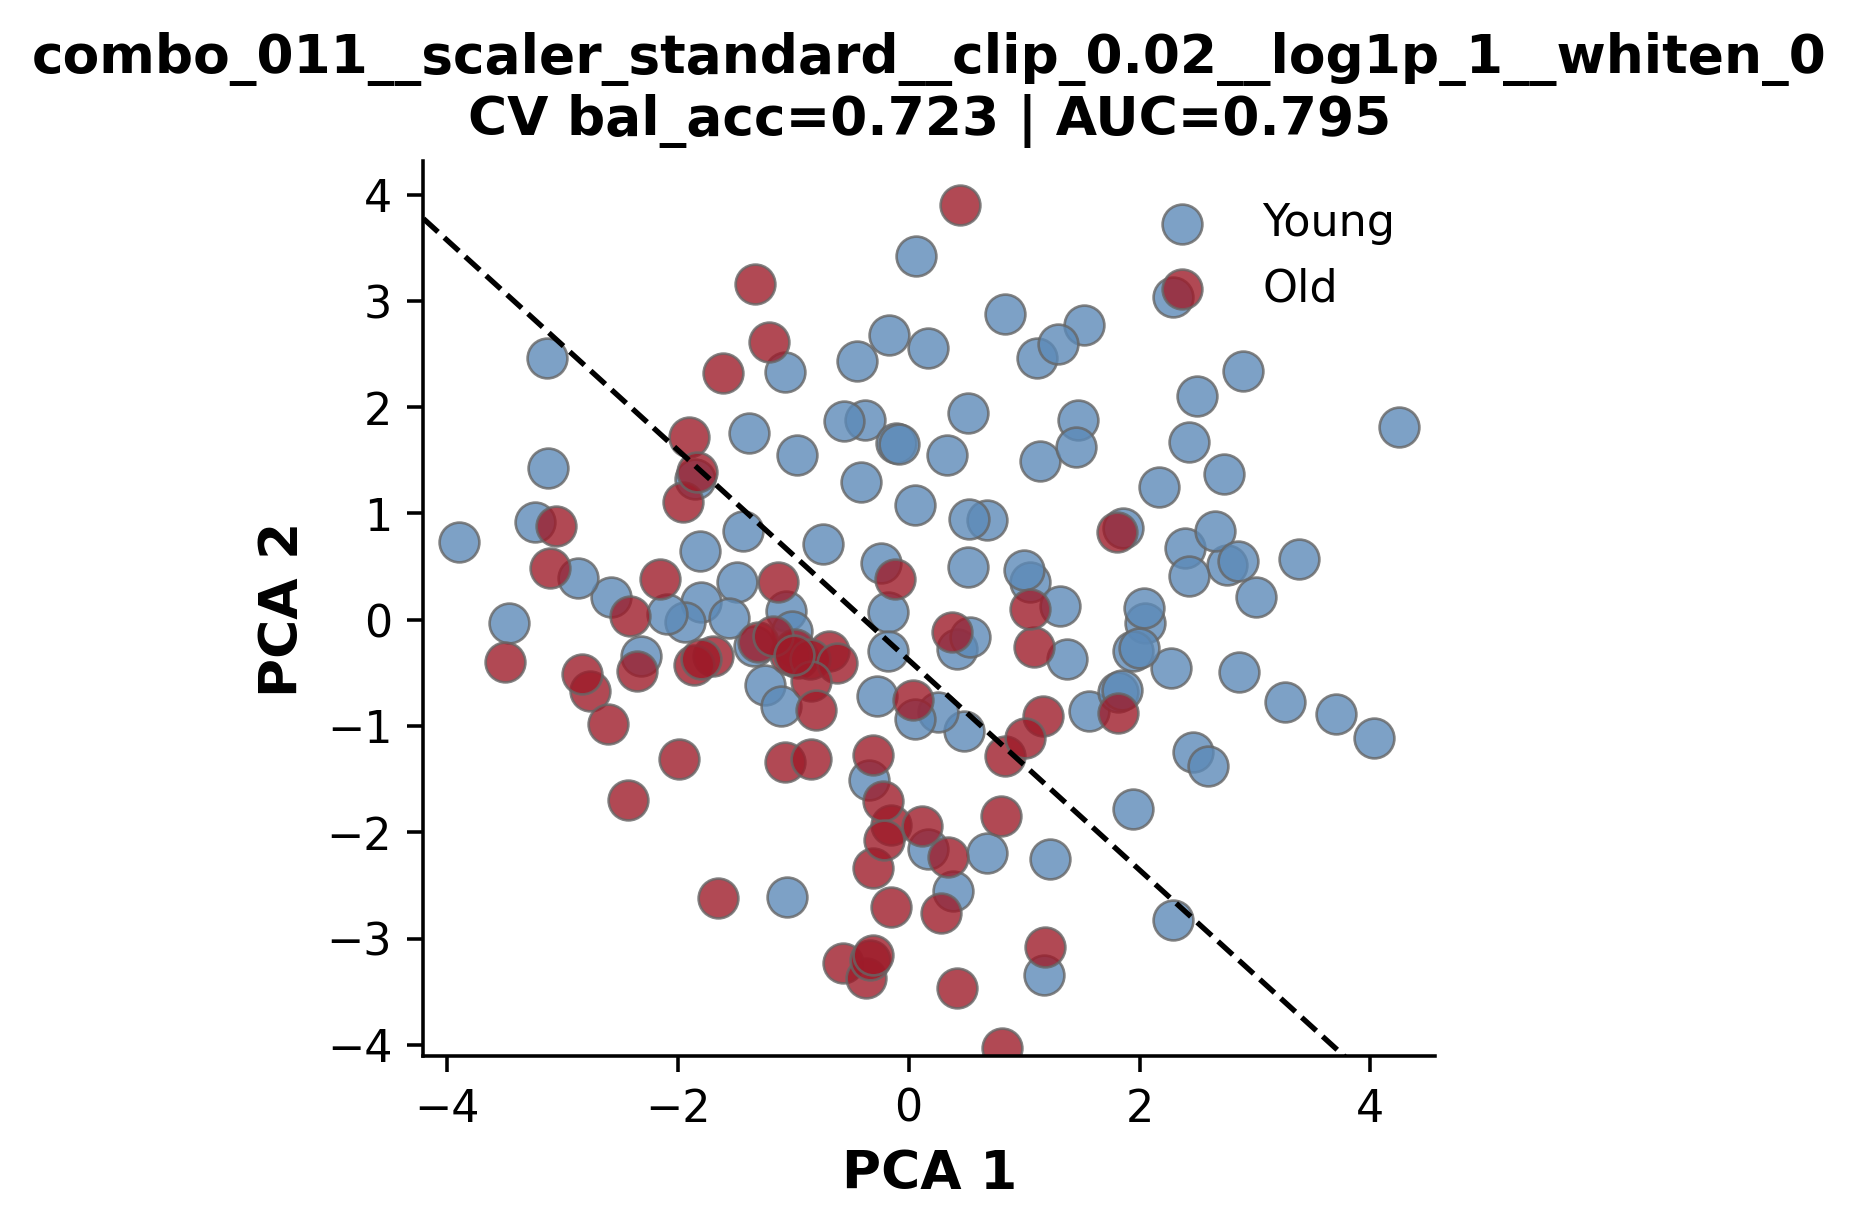

In [8]:
import run_image_feature_young_old_pca12_selected_blurred_grid as blur
blur = importlib.reload(blur)

blur_out = P.OUTPUT_DIR / "blurred_combo011_only"
blur_sum = blur.run_grid(
    features_csv=P.FEATURES_BLURRED_CSV,
    selected_features_csv=P.SELECTED_FEATURES_CSV,
    out_dir=blur_out,
    random_state=42,
    cv_splits=5,
    cv_repeats=5,
    scaler_modes=blur.parse_str_list("standard,robust,minmax"),
    clip_quantiles=blur.parse_float_list("0,0.01,0.02"),
    log1p_options=blur.parse_bool_list("0,1"),
    pca_whiten_options=blur.parse_bool_list("0,1"),
    combo_index=11,
)
display(blur_sum)
row011 = blur_sum.iloc[0]
display(Markdown(
    f"**Blurred combo 011 CV AUC = {row011.cv_roc_auc:.3f}** (paper 0.795). "
    f"`{row011.combo_name}`"
))
display(Image(filename=str(row011.plot_png)))
